# Can ICD codes become useful model features?

The discharge model currently turns a patient's entire diagnosis list into **two numbers**:
`n_diagnoses` (how many) and `charlson_score` (a weighted count of 17 chronic conditions). It
has no way to tell a sepsis admission from a hip fracture.

This notebook asks whether that can be improved, and answers it with evidence rather than
opinion. For every feature proposed in `docs/mimic/icd_feature_engineering.md` it measures:

- **Prevalence** — how many admissions have it. A feature present in 30 admissions out of half a
  million cannot be learned from, however clinically sensible it sounds.
- **Readmission rate** — the 30-day readmission rate among admissions that have it.
- **Lift** — that rate divided by the overall base rate. Lift near 1.0 means the feature carries
  no signal on its own; far from 1.0 means it does.

Univariate lift is a screening tool, not proof: a feature can have lift 1.0 and still matter in
combination, and one with high lift may be redundant with something the model already has. But
it reliably identifies features that are **not worth adding**, which is most of the value.

> Attach a MIMIC-IV dataset with **+ Add Input**. Needs `diagnoses_icd`, `d_icd_diagnoses` and
> `admissions`.

## 0. Load, and build the readmission label

In [19]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

SEARCH_ROOTS = ["/kaggle/input", "../input", "./data", ".","/kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp"]

def find_table(*names):
    hits = []
    for root in SEARCH_ROOTS:
        if not os.path.isdir(root):
            continue
        for name in names:
            for ext in ("csv", "csv.gz", "parquet"):
                hits += glob.glob(f"{root}/**/{name}.{ext}", recursive=True)
    return max(set(hits), key=os.path.getsize) if hits else None

def read_table(path, **kw):
    if path.endswith(".parquet"):
        return pd.read_parquet(path, **({"columns": kw["usecols"]} if "usecols" in kw else {}))
    return pd.read_csv(path, **kw)

dx_path  = find_table("diagnoses_icd", "sample_diagnoses_icd")
adm_path = find_table("admissions", "sample_admissions")
print("diagnoses_icd :", dx_path or "NOT FOUND")
print("admissions    :", adm_path or "NOT FOUND")
if not dx_path or not adm_path:
    raise SystemExit("Attach a MIMIC-IV dataset. Needs diagnoses_icd and admissions.")

dx = read_table(dx_path, usecols=["subject_id", "hadm_id", "seq_num", "icd_code", "icd_version"])
dx["icd_code"] = dx.icd_code.astype(str).str.upper().str.replace(".", "", regex=False).str.strip()
dx["icd_version"] = pd.to_numeric(dx.icd_version, errors="coerce").astype("Int64")
print(f"\n{len(dx):,} diagnosis rows, {dx.hadm_id.nunique():,} admissions")

diagnoses_icd : ../input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp/diagnoses_icd.csv
admissions    : /kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp/admissions.csv

6,364,488 diagnosis rows, 545,497 admissions


In [20]:
adm = read_table(adm_path, usecols=["subject_id", "hadm_id", "admittime", "dischtime",
                                    "admission_type", "hospital_expire_flag"])
for col in ("admittime", "dischtime"):
    adm[col] = pd.to_datetime(adm[col], errors="coerce")

adm = adm.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
adm["next_admit"] = adm.groupby("subject_id").admittime.shift(-1)
adm["next_type"] = adm.groupby("subject_id").admission_type.shift(-1)
adm["days_to_next"] = (adm.next_admit - adm.dischtime).dt.total_seconds() / 86400

# A readmission that was booked in advance is not a failure of the discharge, so
# elective and surgical-same-day returns are excluded. Deaths in hospital are
# dropped entirely: those patients could not be readmitted.
ELECTIVE = {"ELECTIVE", "SURGICAL SAME DAY ADMISSION"}
adm["readmit_30d"] = (
    adm.days_to_next.between(0, 30, inclusive="both")
    & ~adm.next_type.fillna("").str.upper().isin(ELECTIVE)
).astype("int8")

cohort = adm[adm.hospital_expire_flag.eq(0)].copy()
BASE = cohort.readmit_30d.mean()

print(f"cohort admissions      : {len(cohort):,}  (in-hospital deaths removed)")
print(f"30-day unplanned readmission rate : {BASE:.2%}")
print(f"  readmitted            : {cohort.readmit_30d.sum():,}")
print("\nNOTE: this is a simple all-cause definition and will differ slightly from the")
print("phase-1 label, which also filters on discharge disposition. Lift ratios below are")
print("comparable to each other, which is what matters here.")

cohort admissions      : 534,227  (in-hospital deaths removed)
30-day unplanned readmission rate : 19.02%
  readmitted            : 101,603

NOTE: this is a simple all-cause definition and will differ slightly from the
phase-1 label, which also filters on discharge disposition. Lift ratios below are
comparable to each other, which is what matters here.


## 1. Level 0 — unpack the Charlson flags that are already computed

The Phase-1 pipeline maps every diagnosis code to the 17 Charlson conditions, using the
Quan et al. (2005) crosswalk for both ICD-9 and ICD-10. It then **sums them into one number and
throws the 17 flags away.**

The sum tells the model "this patient is a 5". The flags would tell it *which* 5 — a patient
who is 5 from metastatic cancer is a different problem from one who is 5 from diabetes plus
kidney disease plus heart failure.

This is the cheapest possible improvement: the computation already runs.

In [21]:
# Quan et al. (2005), copied verbatim from the Phase-1 notebook so the flags here
# are exactly the ones already being computed and discarded.
CHARLSON = {
    "myocardial_infarction":   (1, r"^(410|412)", r"^(I21|I22|I252)"),
    "congestive_heart_failure":(1, r"^(39891|402(01|11|91)|404(01|03|11|13|91|93)|425[456789]|428)",
                                   r"^(I099|I110|I130|I132|I255|I420|I42[56789]|I43|I50|P290)"),
    "peripheral_vascular":     (1, r"^(0930|437[34]|440|441|443[123456789]|4471|5571|5579|V434)",
                                   r"^(I70|I71|I73[189]|I771|I79[02]|K55[189]|Z95[89])"),
    "cerebrovascular":         (1, r"^(36234|43[0-8])", r"^(G4[56]|H340|I6[0-9])"),
    "dementia":                (1, r"^(290|2941|3312)", r"^(F0[0-3]|F051|G30|G311)"),
    "chronic_pulmonary":       (1, r"^(4168|4169|49[0-6]|50[0-5]|5064|5081|5088)",
                                   r"^(I27[89]|J4[0-7]|J6[0-7]|J684|J70[13])"),
    "rheumatic":               (1, r"^(4465|710[0-4]|714[0128]|725)",
                                   r"^(M0[56]|M315|M3[234]|M35[13]|M360)"),
    "peptic_ulcer":            (1, r"^(53[1-4])", r"^(K2[5-8])"),
    "mild_liver":              (1, r"^(070[23][23]|070[45]4|0706|0709|57[01]|5733|5734|5738|5739|V427)",
                                   r"^(B18|K70[0-39]|K71[3-57]|K7[34]|K76[02-49]|Z944)"),
    "diabetes_uncomplicated":  (1, r"^(250[0-3]|2508|2509)", r"^(E1[0-4][01689])"),
    "diabetes_complicated":    (2, r"^(250[4-7])", r"^(E1[0-4][2-57])"),
    "hemiplegia":              (2, r"^(3341|342|343|344[0-6]|3449)",
                                   r"^(G041|G114|G80[12]|G8[12]|G83[0-49])"),
    "renal_disease":           (2, r"^(40301|40311|40391|40402|40403|40412|40413|40492|40493|58[26]|5830[0-7]|585|586|5880|V420|V451|V56)",
                                   r"^(I120|I131|N03[2-7]|N05[2-7]|N1[89]|N250|Z49[0-2]|Z940|Z992)"),
    "malignancy":              (2, r"^(1[4-9][0-9]|20[0-8]|2386)",
                                   r"^(C[0-2][0-6]|C3[0-4]|C3[789]|C4[01]|C43|C4[5-9]|C5[0-8]|C6[0-9]|C7[0-6]|C8[1-5]|C88|C9[0-7])"),
    "severe_liver":            (3, r"^(456[012]|572[2-8])",
                                   r"^(I85[09]|I864|I982|K704|K711|K721|K729|K76[5-7])"),
    "metastatic_cancer":       (6, r"^(19[6-9])", r"^(C7[789]|C80)"),
    "hiv_aids":                (6, r"^(04[2-4])", r"^(B2[0-4])"),
}

is9 = dx.icd_version.eq(9)
feat = pd.DataFrame(index=pd.Index(cohort.hadm_id.unique(), name="hadm_id"))

for cond, (w, p9, p10) in CHARLSON.items():
    hit = np.where(is9, dx.icd_code.str.match(p9), dx.icd_code.str.match(p10))
    feat[f"cci_{cond}"] = feat.index.isin(dx.loc[hit, "hadm_id"].unique()).astype("int8")

# Charlson hierarchy: the severe form supersedes the mild one.
feat.loc[feat.cci_diabetes_complicated.eq(1), "cci_diabetes_uncomplicated"] = 0
feat.loc[feat.cci_severe_liver.eq(1), "cci_mild_liver"] = 0
feat.loc[feat.cci_metastatic_cancer.eq(1), "cci_malignancy"] = 0

print(f"{len(CHARLSON)} Charlson flags computed for {len(feat):,} admissions")
feat.head(3)

17 Charlson flags computed for 534,227 admissions


,cci_myocardial_infarction,cci_congestive_heart_failure,cci_peripheral_vascular,cci_cerebrovascular,cci_dementia,cci_chronic_pulmonary,cci_rheumatic,cci_peptic_ulcer,cci_mild_liver,cci_diabetes_uncomplicated,cci_diabetes_complicated,cci_hemiplegia,cci_renal_disease,cci_malignancy,cci_severe_liver,cci_metastatic_cancer,cci_hiv_aids
hadm_id,,,,,,,,,,,,,,,,,
22595853,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
22841357,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
29079034,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0


## 2. Level 1 — one flag per ICD chapter

Twenty features, one per body-system family. Coarse, but it is the difference between the model
knowing "14 diagnoses" and knowing "14 diagnoses, and one of them is a kidney problem".

In [22]:
ICD10_CHAPTERS = [
    ("A00","B99","infectious"), ("C00","D49","neoplasm"), ("D50","D89","blood"),
    ("E00","E89","endocrine"), ("F01","F99","mental"), ("G00","G99","nervous"),
    ("H00","H59","nervous"), ("H60","H95","nervous"), ("I00","I99","circulatory"),
    ("J00","J99","respiratory"), ("K00","K95","digestive"), ("L00","L99","skin"),
    ("M00","M99","musculoskeletal"), ("N00","N99","genitourinary"),
    ("O00","O9A","obstetric"), ("P00","P96","perinatal"), ("Q00","Q99","congenital"),
    ("R00","R99","symptoms"), ("S00","T88","injury"), ("U00","U85","special"),
    ("V00","Y99","external_cause"), ("Z00","Z99","health_status"),
]
ICD9_CHAPTERS = [
    (1,139,"infectious"), (140,239,"neoplasm"), (240,279,"endocrine"), (280,289,"blood"),
    (290,319,"mental"), (320,389,"nervous"), (390,459,"circulatory"), (460,519,"respiratory"),
    (520,579,"digestive"), (580,629,"genitourinary"), (630,679,"obstetric"),
    (680,709,"skin"), (710,739,"musculoskeletal"), (740,759,"congenital"),
    (760,779,"perinatal"), (780,799,"symptoms"), (800,999,"injury"),
]

def chapter_of(code, version):
    c = str(code).strip().upper()
    if not c:
        return "unclassified"
    if version == 9:
        if c[0] == "E":
            return "external_cause"
        if c[0] == "V":
            return "health_status"
        try:
            head = int(c[:3])
        except ValueError:
            return "unclassified"
        for lo, hi, name in ICD9_CHAPTERS:
            if lo <= head <= hi:
                return name
        return "unclassified"
    head = c[:3]
    for lo, hi, name in ICD10_CHAPTERS:
        if lo <= head <= hi:
            return name
    return "unclassified"

dx["chapter"] = [chapter_of(c, v) for c, v in zip(dx.icd_code, dx.icd_version)]
dx["category"] = dx.icd_code.str.slice(0, 3)

chapter_flags = (dx.assign(one=1)
                   .pivot_table(index="hadm_id", columns="chapter", values="one",
                                aggfunc="max", fill_value=0))
chapter_flags.columns = [f"chap_{c}" for c in chapter_flags.columns]
feat = feat.join(chapter_flags.astype("int8"), how="left").fillna(0)

print(f"{chapter_flags.shape[1]} chapter flags added")
print(feat.filter(like="chap_").mean().sort_values(ascending=False).round(3).to_string())

20 chapter flags added
chap_health_status      0.722
chap_circulatory        0.641
chap_endocrine          0.622
chap_symptoms           0.477
chap_mental             0.437
chap_digestive          0.420
chap_nervous            0.367
chap_genitourinary      0.341
chap_blood              0.307
chap_musculoskeletal    0.294
chap_respiratory        0.281
chap_external_cause     0.273
chap_injury             0.253
chap_infectious         0.184
chap_neoplasm           0.175
chap_skin               0.108
chap_obstetric          0.050
chap_congenital         0.026
chap_special            0.007
chap_perinatal          0.000


## 3. Level 2 — features from the shape of the diagnosis list

Not *which* conditions, but *how the list is shaped*. These cost nothing to compute and describe
something the two current features cannot: how scattered the patient's problems are, how much of
the list is social rather than medical, and whether anything went wrong during the stay.

In [23]:
g = dx.groupby("hadm_id")
shape = pd.DataFrame({
    "n_chapters": g.chapter.nunique(),
    "n_categories": g.category.nunique(),
})
shape["dx_per_chapter"] = (g.size() / shape.n_chapters).round(2)

# Z / V codes: history, status and long-term treatment rather than active illness.
# "long term use of anticoagulants" is not a disease but is highly informative.
shape["n_status_codes"] = dx[dx.chapter.eq("health_status")].groupby("hadm_id").size()
# Symptom codes without a diagnosis behind them - chest pain, ascites. A list
# heavy in these suggests the stay ended without a settled explanation.
shape["n_symptom_codes"] = dx[dx.chapter.eq("symptoms")].groupby("hadm_id").size()

# In-hospital complications. ICD-10 T80-T88 and ICD-9 996-999 are coded when
# something went wrong during THIS stay - a device infection, a procedural
# mishap. Known at discharge, so legitimate for a discharge-time model.
comp = dx[((dx.icd_version.eq(10)) & dx.icd_code.str.match(r"^T8[0-8]")) |
          ((dx.icd_version.eq(9)) & dx.icd_code.str.match(r"^99[6-9]"))]
shape["n_complication_codes"] = comp.groupby("hadm_id").size()

# The chapter of the PRINCIPAL diagnosis, as a category. Ranked first by the
# coder as the reason for admission, it deserves its own feature rather than
# being averaged into the rest.
principal = (dx[dx.seq_num.eq(1)].sort_values("icd_version")
               .drop_duplicates("hadm_id").set_index("hadm_id"))
shape["principal_chapter"] = principal.chapter

shape = shape.reindex(feat.index).fillna({"n_chapters": 0, "n_categories": 0,
                                          "dx_per_chapter": 0, "n_status_codes": 0,
                                          "n_symptom_codes": 0, "n_complication_codes": 0})
feat = feat.join(shape)
print(shape.drop(columns="principal_chapter").describe().round(2).to_string())
print("\nprincipal diagnosis chapter, share of admissions:")
print((shape.principal_chapter.value_counts(normalize=True) * 100).round(1).head(12).to_string())

       n_chapters  n_categories  dx_per_chapter  n_status_codes  n_symptom_codes  n_complication_codes
count   534227.00     534227.00       534227.00       534227.00        534227.00             534227.00
mean         5.98         10.59            1.84            1.88             0.84                  0.12
std          2.95          6.64            0.63            1.90             1.18                  0.40
min          0.00          0.00            0.00            0.00             0.00                  0.00
25%          4.00          6.00            1.38            0.00             0.00                  0.00
50%          6.00          9.00            1.75            1.00             0.00                  0.00
75%          8.00         14.00            2.20            3.00             1.00                  0.00
max         17.00         45.00           11.00           21.00            16.00                  8.00

principal diagnosis chapter, share of admissions:
principal_chapter
circ

## 4. Level 3 — clinically real combinations

Some pairs of conditions are more dangerous together than apart, and a model given only separate
flags has to discover that from the data. Naming them directly is cheap and makes the
explanation on a driver card immediately readable to a clinician.

In [24]:
f = feat
feat["combo_cardiorenal"] = ((f.cci_congestive_heart_failure.eq(1)) &
                             (f.cci_renal_disease.eq(1))).astype("int8")
feat["combo_diabetes_renal"] = (((f.cci_diabetes_complicated.eq(1)) |
                                 (f.cci_diabetes_uncomplicated.eq(1))) &
                                (f.cci_renal_disease.eq(1))).astype("int8")
feat["combo_cardiopulmonary"] = ((f.cci_congestive_heart_failure.eq(1)) &
                                 (f.cci_chronic_pulmonary.eq(1))).astype("int8")
feat["combo_cancer_plus_organ"] = (((f.cci_malignancy.eq(1)) | (f.cci_metastatic_cancer.eq(1))) &
                                   ((f.cci_renal_disease.eq(1)) |
                                    (f.cci_congestive_heart_failure.eq(1)))).astype("int8")

# Atrial fibrillation with heart failure - a recognised high-risk pairing that
# Charlson does not capture, because AF is not a Charlson condition at all.
af = dx[((dx.icd_version.eq(10)) & dx.icd_code.str.match(r"^I48")) |
        ((dx.icd_version.eq(9)) & dx.icd_code.str.match(r"^42731"))].hadm_id.unique()
feat["dx_atrial_fibrillation"] = feat.index.isin(af).astype("int8")
feat["combo_af_heart_failure"] = ((feat.dx_atrial_fibrillation.eq(1)) &
                                  (f.cci_congestive_heart_failure.eq(1))).astype("int8")

# Sepsis, likewise absent from Charlson and a strong driver of early return.
sep = dx[((dx.icd_version.eq(10)) & dx.icd_code.str.match(r"^(A40|A41|R652)")) |
         ((dx.icd_version.eq(9)) & dx.icd_code.str.match(r"^(038|9959[12])"))].hadm_id.unique()
feat["dx_sepsis"] = feat.index.isin(sep).astype("int8")

print(feat.filter(regex="^(combo_|dx_)").mean().sort_values(ascending=False).round(4).to_string())

dx_per_chapter             1.8364
dx_atrial_fibrillation     0.1413
combo_diabetes_renal       0.0812
combo_af_heart_failure     0.0683
combo_cardiorenal          0.0679
combo_cardiopulmonary      0.0509
dx_sepsis                  0.0337
combo_cancer_plus_organ    0.0295


## 5. Does any of it carry signal?

For every proposed feature: how common it is, the readmission rate among admissions that have
it, and the lift against the base rate.

**How to read this.** Lift of 1.0 means the feature tells you nothing on its own. Lift of 1.5
means those admissions come back half again as often as average. Prevalence below roughly 0.5%
means the feature is too rare to learn from regardless of its lift, and is marked accordingly.

In [25]:
label = cohort.set_index("hadm_id").readmit_30d.reindex(feat.index)
COUNT_COLS = ("n_chapters", "n_categories", "n_status_codes",
              "n_symptom_codes", "n_complication_codes", "dx_per_chapter")
binary_cols = [c for c in feat.columns
               if c not in COUNT_COLS and feat[c].dtype != object
               and feat[c].dropna().isin([0, 1]).all()]

rows = []
for c in binary_cols:
    present = feat[c].eq(1)
    n = int(present.sum())
    if n == 0:
        continue
    rate = float(label[present].mean())
    rows.append({"feature": c, "prevalence": n / len(feat), "n": n,
                 "readmit_rate": rate, "lift": rate / BASE})

signal = pd.DataFrame(rows).sort_values("lift", ascending=False)
signal["verdict"] = np.where(
    signal.prevalence < 0.005, "too rare",
    np.where(signal.lift.between(0.9, 1.1), "no signal alone", "useful"))

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print(f"base readmission rate: {BASE:.2%}\n")
signal.reset_index(drop=True)

base readmission rate: 19.02%



,feature,prevalence,n,readmit_rate,lift,verdict
0,cci_severe_liver,0.024,12793,0.353,1.856,useful
1,chap_perinatal,0.000,73,0.342,1.801,too rare
2,cci_hiv_aids,0.007,3667,0.296,1.557,useful
3,combo_cancer_plus_organ,0.030,15780,0.293,1.543,useful
4,cci_malignancy,0.085,45320,0.282,1.484,useful
5,cci_metastatic_cancer,0.049,26127,0.281,1.478,useful
6,combo_cardiorenal,0.068,36280,0.269,1.415,useful
7,chap_neoplasm,0.175,93258,0.258,1.355,useful
8,combo_diabetes_renal,0.081,43390,0.257,1.352,useful
9,cci_mild_liver,0.054,28809,0.255,1.340,useful


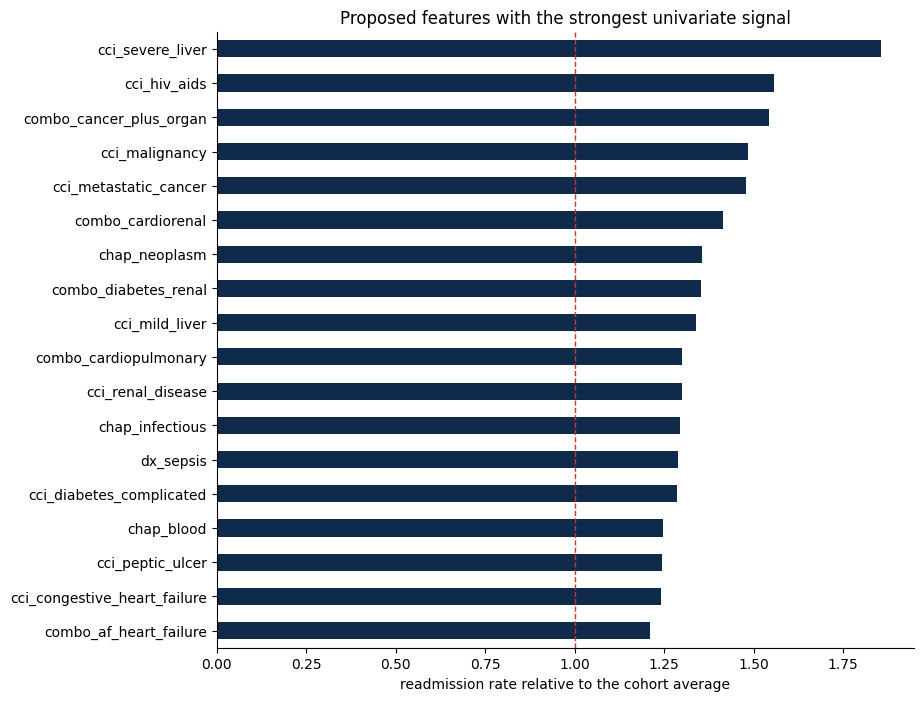

In [26]:
top = signal[signal.verdict.eq("useful")].head(18).sort_values("lift")
ax = top.plot(kind="barh", x="feature", y="lift", figsize=(9, 8),
              legend=False, color="#0F2A4A")
ax.axvline(1.0, color="#C0392B", linestyle="--", linewidth=1)
ax.set_xlabel("readmission rate relative to the cohort average")
ax.set_ylabel("")
ax.set_title("Proposed features with the strongest univariate signal")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

In [27]:
# The continuous shape features, cut into bands.
for col in ("n_chapters", "n_categories", "n_status_codes", "n_complication_codes"):
    s = feat[col].fillna(0)
    bands = pd.qcut(s, 5, duplicates="drop") if s.nunique() > 5 else s
    tab = pd.DataFrame({"admissions": label.groupby(bands).size(),
                        "readmit_rate": label.groupby(bands).mean()})
    tab["lift"] = tab.readmit_rate / BASE
    print(f"\n{col.upper()}")
    print(tab.round(3).to_string())


N_CHAPTERS
               admissions  readmit_rate  lift
n_chapters                                   
(-0.001, 3.0]      124276         0.147 0.772
(3.0, 5.0]         123393         0.156 0.822
(5.0, 7.0]         124198         0.192 1.008
(7.0, 9.0]          92337         0.229 1.205
(9.0, 17.0]         70023         0.273 1.435

N_CATEGORIES
               admissions  readmit_rate  lift
n_categories                                 
(-0.001, 5.0]      132117         0.148 0.781
(5.0, 8.0]         104565         0.157 0.823
(8.0, 11.0]         93540         0.183 0.963
(11.0, 16.0]       109307         0.215 1.129
(16.0, 45.0]        94698         0.264 1.389

N_STATUS_CODES
                admissions  readmit_rate  lift
n_status_codes                                
(-0.001, 1.0]       277047         0.172 0.904
(1.0, 2.0]           97863         0.188 0.988
(2.0, 3.0]           65132         0.205 1.076
(3.0, 21.0]          94185         0.236 1.241

N_COMPLICATION_CODES
          

In [28]:
# And the principal diagnosis chapter, which the model currently cannot see at all.
pc = feat.principal_chapter.fillna("missing")
tab = pd.DataFrame({"admissions": label.groupby(pc).size(),
                    "readmit_rate": label.groupby(pc).mean()})
tab["lift"] = (tab.readmit_rate / BASE).round(2)
print("READMISSION RATE BY PRINCIPAL DIAGNOSIS CHAPTER\n")
print(tab.sort_values("lift", ascending=False).round(3).to_string())

READMISSION RATE BY PRINCIPAL DIAGNOSIS CHAPTER

                   admissions  readmit_rate  lift
principal_chapter                                
health_status           12406         0.322 1.690
mental                  42512         0.317 1.670
external_cause              7         0.286 1.500
blood                    6214         0.255 1.340
missing                   522         0.239 1.260
neoplasm                32404         0.226 1.190
infectious              21402         0.218 1.140
endocrine               20505         0.212 1.110
digestive               61134         0.208 1.090
respiratory             26302         0.190 1.000
genitourinary           23461         0.189 1.000
circulatory             87534         0.171 0.900
injury                  64227         0.161 0.850
nervous                 17497         0.152 0.800
skin                    10310         0.151 0.800
symptoms                51622         0.150 0.790
special                  1772         0.142 0.750
c

## 6. The weekly monitoring question

The other half of this: post-discharge monitoring currently applies the **same rule to every
patient**. A 2 kg weekly weight gain adds the same points whether the patient has heart failure
or a new knee.

To make those rules disease-specific, each patient needs a **clinical group** — a small label
derived from their codes that says which signals matter for them. The groups below are chosen so
that each one implies a genuinely different monitoring plan, not merely a different label.

The cell measures how many admissions fall into each group and how often they come back, which
determines whether the group is worth having its own rule set.

In [29]:
# Ordered: the FIRST match wins, so the group that most determines the
# monitoring plan is tested first. A patient with heart failure and diabetes is
# monitored as heart failure, because that is what will bring them back.
GROUP_RULES = [
    ("heart_failure",  lambda f: f.cci_congestive_heart_failure.eq(1)),
    ("renal",          lambda f: f.cci_renal_disease.eq(1)),
    ("respiratory",    lambda f: f.cci_chronic_pulmonary.eq(1)),
    ("sepsis_infection", lambda f: f.dx_sepsis.eq(1)),
    ("oncology",       lambda f: (f.cci_metastatic_cancer.eq(1)) | (f.cci_malignancy.eq(1))),
    ("diabetes",       lambda f: (f.cci_diabetes_complicated.eq(1)) |
                                 (f.cci_diabetes_uncomplicated.eq(1))),
    ("cardiac_other",  lambda f: (f.cci_myocardial_infarction.eq(1)) |
                                 (f.dx_atrial_fibrillation.eq(1)) |
                                 (f.cci_peripheral_vascular.eq(1))),
    ("neuro_stroke",   lambda f: (f.cci_cerebrovascular.eq(1)) | (f.cci_hemiplegia.eq(1))),
    ("surgical_injury", lambda f: (f.get("chap_injury", 0) == 1) |
                                  (f.n_complication_codes.fillna(0) > 0)),
    ("mental_health",  lambda f: f.get("chap_mental", 0) == 1),
]

group = pd.Series("general", index=feat.index, dtype=object)
for name, rule in reversed(GROUP_RULES):      # reversed so earlier rules overwrite later ones
    group[rule(feat).fillna(False).values] = name
feat["clinical_group"] = group

tab = pd.DataFrame({"admissions": label.groupby(group).size(),
                    "share": label.groupby(group).size() / len(feat),
                    "readmit_rate": label.groupby(group).mean()})
tab["lift"] = tab.readmit_rate / BASE
print("CLINICAL GROUPS FOR WEEKLY MONITORING\n")
print(tab.sort_values("admissions", ascending=False).round(3).to_string())
print(f"\nbase readmission rate: {BASE:.2%}")
print("\nA group is worth its own rule set when it is BOTH common enough to matter and")
print("different enough from the average to justify different thresholds.")

CLINICAL GROUPS FOR WEEKLY MONITORING

                  admissions  share  readmit_rate  lift
general                89224  0.167         0.100 0.528
heart_failure          80548  0.151         0.236 1.243
mental_health          73094  0.137         0.236 1.242
respiratory            61832  0.116         0.192 1.010
diabetes               46531  0.087         0.169 0.888
renal                  46430  0.087         0.230 1.209
oncology               44821  0.084         0.277 1.456
surgical_injury        44713  0.084         0.144 0.758
cardiac_other          28551  0.053         0.138 0.724
neuro_stroke           10073  0.019         0.122 0.641
sepsis_infection        8410  0.016         0.229 1.202

base readmission rate: 19.02%

A group is worth its own rule set when it is BOTH common enough to matter and
different enough from the average to justify different thresholds.


## 7. Export the engineered feature table

Two files. The per-admission matrix is what a retrain would join onto the existing
`phase1_matrix.parquet` on `hadm_id`; the signal report is the evidence for which columns are
worth keeping.

In [30]:
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

out = feat.copy()
out["readmit_30d"] = label
out.to_parquet(f"{OUT}/icd_engineered_features.parquet")
signal.to_csv(f"{OUT}/icd_feature_signal_report.csv", index=False)

print(f"icd_engineered_features.parquet : {out.shape[0]:,} rows x {out.shape[1]} columns")
print(f"icd_feature_signal_report.csv   : {len(signal)} features scored")
print("\nColumn groups:")
for prefix, desc in (("cci_", "Charlson condition flags"),
                     ("chap_", "ICD chapter flags"),
                     ("combo_", "clinically meaningful combinations"),
                     ("dx_", "individual high-value diagnoses"),
                     ("n_", "diagnosis-list shape")):
    cols = [c for c in out.columns if c.startswith(prefix)]
    print(f"  {prefix:<8} {len(cols):>3}  {desc}")
print(f"  {'other':<8} {len([c for c in out.columns if not c.split('_')[0] + '_' in ('cci_','chap_','combo_','dx_','n_')]):>3}"
      "  clinical_group, principal_chapter, dx_per_chapter, label")

icd_engineered_features.parquet : 534,227 rows x 53 columns
icd_feature_signal_report.csv   : 44 features scored

Column groups:
  cci_      17  Charlson condition flags
  chap_     20  ICD chapter flags
  combo_     5  clinically meaningful combinations
  dx_        3  individual high-value diagnoses
  n_         5  diagnosis-list shape
  other      3  clinical_group, principal_chapter, dx_per_chapter, label


In [31]:
# The headline, for pasting back into docs/mimic/icd_feature_engineering.md
useful = signal[signal.verdict.eq("useful")]
print("ICD FEATURE ENGINEERING - EVIDENCE SUMMARY")
print(f"  cohort                    : {len(feat):,} admissions")
print(f"  base readmission rate     : {BASE:.2%}")
print(f"  features proposed         : {len(signal)}")
print(f"  with usable signal        : {len(useful)}")
print(f"  too rare to learn from    : {(signal.verdict == 'too rare').sum()}")
print(f"  no univariate signal      : {(signal.verdict == 'no signal alone').sum()}")
print("\n  strongest 10 by lift:")
for _, r in useful.head(10).iterrows():
    print(f"    {r.feature:<34} {r.prevalence:>6.1%} of admissions   "
          f"readmit {r.readmit_rate:>6.1%}   lift {r.lift:.2f}")
print("\n  clinical groups for weekly monitoring:")
for grp, row in tab.sort_values("admissions", ascending=False).iterrows():
    print(f"    {grp:<18} {row.share:>6.1%} of admissions   "
          f"readmit {row.readmit_rate:>6.1%}   lift {row.lift:.2f}")

ICD FEATURE ENGINEERING - EVIDENCE SUMMARY
  cohort                    : 534,227 admissions
  base readmission rate     : 19.02%
  features proposed         : 44
  with usable signal        : 30
  too rare to learn from    : 1
  no univariate signal      : 13

  strongest 10 by lift:
    cci_severe_liver                     2.4% of admissions   readmit  35.3%   lift 1.86
    cci_hiv_aids                         0.7% of admissions   readmit  29.6%   lift 1.56
    combo_cancer_plus_organ              3.0% of admissions   readmit  29.3%   lift 1.54
    cci_malignancy                       8.5% of admissions   readmit  28.2%   lift 1.48
    cci_metastatic_cancer                4.9% of admissions   readmit  28.1%   lift 1.48
    combo_cardiorenal                    6.8% of admissions   readmit  26.9%   lift 1.42
    chap_neoplasm                       17.5% of admissions   readmit  25.8%   lift 1.35
    combo_diabetes_renal                 8.1% of admissions   readmit  25.7%   lift 1.35
   